# Island Reversal — a quantitative teardown 🔬
### Objective gap-island detector · forward excess over base rate at 5/10/20/40d · one-sample + HAC *t* · same-tape random-date placebo · gap-strictness sweep · the island-bottom symmetry myth check · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The island reversal is a *gap-defined* figure, so the detector can be genuinely objective — and the result is a clean **None × Mirage**: the bearish island top has a **negative** forward excess, and the bullish island bottom's high *t* is manufactured by the tape's up-drift (the placebo refuses it).

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket (SPY + 29), names still trading in 2026 — a *survivor* panel that tilts post-island returns mildly **up**, i.e. *against* the headline (bearish) short. Real data: yfinance daily auto-adjusted OHLC, 2005-01-03→2026-05-29 (as-of 2026-05-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from island_reversal import data, strategy as st

ASOF = "2026-05-31"
GAP = 0.01
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:pd.Timestamp(ASOF)]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real island cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'bars': 5385, 'n_names': 30, 'fingerprint': 'bcc8dc7157c7', 'gap_pct': 1.0, 'n_tops': 75, 'n_bottoms': 97, 'spy_tops': 3, 'spy_bottoms': 3, 'top': [(5, 75, -0.705, -1.025, 45, -1.27, -1.21, 0.641, -0.805), (10, 75, -1.275, -1.906, 39, -1.59, -1.36, 0.678, -1.375), (20, 75, -0.64, -1.901, 45, -0.55, -0.49, 0.562, -0.74), (40, 73, -0.336, -2.794, 49, -0.22, -0.2, 0.524, -0.436)], 'bot': [(5, 97, 0.762, 1.085, 60, 1.77, 1.74, 0.337), (10, 96, 0.328, 0.965, 49, 0.48, 0.51, 0.454), (20, 96, 2.022, 3.294, 59, 2.04, 2.4, 0.292), (40, 94, 5.284, 7.762, 69, 4.22, 4.29, 0.163)], 'robust': [(0.5, 198, -0.551, -1.31, 0.616), (1.0, 75, -1.275, -1.59, 0.673), (2.0, 17, -0.989, -0.53, 0.598)], 'spy': [(5, 3, -1.3, -1.537, -0.73, 0.86), (10, 3, -0.907, -1.376, -1.37, 0.699), (20, 3, -1.067, -2.004, -0.47, 0.654), (40, 3, -5.15, -6.997, -1.81, 0.946)], 'syn': [(0.0, 160, 158, 158, -0.58, -1.5, 0.627, 47), (0.25, 160, 158, 158, 18.33, 59.38, 0.0, 100)]}


real island cache present: True | names: 30 | bars: 5385


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Island-top short excess **-0.70%** at 5d, **-1.27%** at 10d — one-sample **t = -1.59** (HAC -1.36), placebo **p = 0.678**. Never clears |t| = 2; negative at every horizon. |
| **Tradability** | `MIRAGE` | Net of 5 bps/leg the short is **-1.38%** (10d); the island-bottom long's t>2 (40d t = 4.22) sits **inside the placebo cloud** (p = 0.163). Pure beta. |
| **Reliable reversal?** | `BUSTED` | Asymmetric: bearish side **loses** (fights up-drift), bullish side only **rides** drift (high t, p = 0.163). Neither works on its own merits. |

> 💡 In plain words: the gap-island figure carries no exhaustion information — the bearish short loses, the bullish long is just the market drifting up, and the placebo (not the *t*) is what tells them apart.

## 1 · The claim, steelmanned

Let an **island top** be: a bar $g_1$ that gaps up ($O_{g_1} \ge (1+\gamma)\,H_{g_1-1}$), an island of $1..m$ bars whose lows never fall back to $H_{g_1-1}$ (the gap stays open), and a sealing bar $g_2$ that gaps down below the island's low *and* back inside the pre-gap range. The signal is a **short** at $g_2$. For each confirmed island let $r_i(H)$ be the forward $H$-day return entered **one day after** $g_2$, and $\bar b$ the name's own (direction-matched) base rate. The figure's edge is the pooled **excess**

$$\widehat{\mu}(H) = \frac{1}{n}\sum_i \big(d\,r_i(H) - \bar b\big),\qquad d = -1\ \text{(top, short)},\ +1\ \text{(bottom, long)}.$$

- **H₁ (the figure reverses).** $\widehat{\mu}(H) > 0$ and significant for some $H$, on the bearish **top** side (the canonical figure).
- **H₂ (deployable).** $\widehat{\mu}(H)$ survives one-way costs × turnover.
- **H₃ (symmetric).** The bullish **bottom** works on its own merits — i.e. beats a same-tape random-date placebo, not just a zero baseline.

We find **H₁ rejected** (top excess negative, |t| < 2), **H₂ rejected** (net worse), **H₃ rejected** (bottom's t>2 but placebo p ≈ 0.16 — it's drift, not the figure). The shape carries no exhaustion signal.

## 2 · So what? — why the placebo, not the *t*, is the arbiter

The Signal test is a one-sample $t$ of the pooled excess against zero, plus a Newey-West (HAC) $t$ for clustered islands:

$$t = \frac{\widehat{\mu}}{s/\sqrt n},\qquad t_{\text{HAC}} = \frac{\widehat{\mu}}{\sqrt{\widehat{\Omega}_{\text{NW}}/n}}.$$

But on a **drifting** asset over multi-week holds, a one-sample $t$ against *zero* can clear 2 on drift alone — exactly the island-**bottom** trap. So the real arbiter is a **same-tape random-date placebo**: draw thousands of random entries (same count per name, same horizon, same base-rate subtraction) and compute $p = \Pr[\text{random excess} \ge \text{observed}]$. If random matches the figure, the figure adds nothing — *whatever the $t$ says*. This is the single discipline that separates a chart figure from the drift it rides on.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket (SPY + 29; yfinance auto-adjusted daily OHLC, 2005-01-03→2026-05-29, **5,385** bars, fingerprint `bcc8dc7157c7`). **Survivor** panel — named on the Signal axis.
- **Detector.** Gap threshold **1%**; island 1–3 bars that never fill the first gap; sealing gap = first opposite gap re-crossing the island's far edge and back inside the pre-gap range. Non-overlapping. Chart figures are subjective — this is the closest mechanical rule, stated openly.
- **Timing.** Signal at the sealing-gap close; enter the close **1 day later** (no look-ahead); hold $H\in\{5,10,20,40\}$; drop windows that overrun the tape.
- **Edge.** Pooled excess of the trade (top = short, bottom = long) over each name's own direction-matched base rate.
- **Null #1 — one-sample & HAC t** of the pooled excess vs 0.
- **Null #2 — same-tape random-date placebo** (5,000 draws): the honest drift control.
- **Costs.** 5 bps one-way × 2 legs.
- **Myth-check.** The island **bottom** (symmetry); **SPY-only** (the hook).
- **Positive control.** A deterministic panel with a **planted** post-island reversal: zero edge must NOT beat the placebo; a large edge must light up.

## 4 · The teardown

### 4a · The island top across horizons — negative everywhere

The pooled short excess at each horizon with its one-sample *t*. A real bearish reversal would sit **above** zero with *t* climbing past 2; this does the opposite.

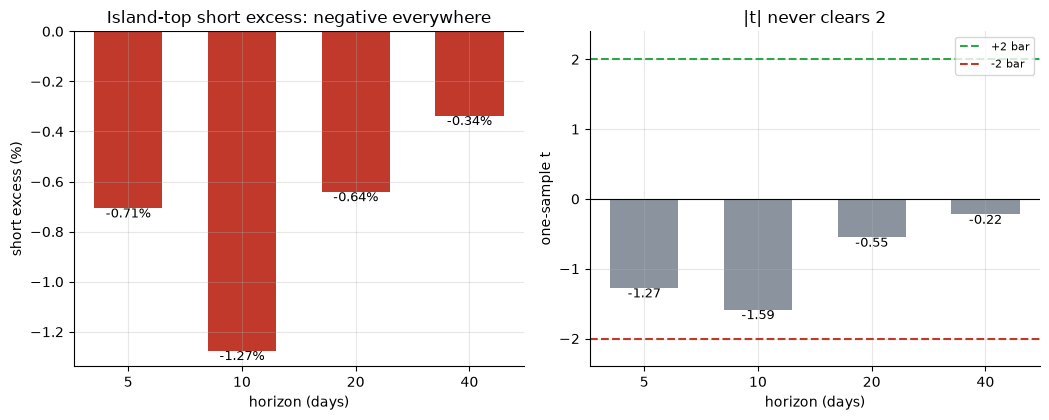

top excess: [-0.71, -1.27, -0.64, -0.34]
top t: [-1.27, -1.59, -0.55, -0.22]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    rs = [st.run_experiment(PANEL, horizon=h, side='top', gap_pct=GAP, n_draws=5000) for h in hs]
    exc = [r['mean']*100 for r in rs]; tt = [r['t'] for r in rs]
else:
    exc = [r[2] for r in R['top']]; tt = [r[5] for r in R['top']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([str(h) for h in hs], exc, color=RED, width=.6); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(exc): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
a1.set_xlabel('horizon (days)'); a1.set_ylabel('short excess (%)'); a1.set_title('Island-top short excess: negative everywhere')
a2.bar([str(h) for h in hs], tt, color=GREY, width=.6)
a2.axhline(2, ls='--', c=GREEN, label='+2 bar'); a2.axhline(-2, ls='--', c=RED, label='-2 bar')
a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(tt): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('one-sample t'); a2.set_ylim(-2.4,2.4)
a2.set_title('|t| never clears 2'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('top excess:', [round(v,2) for v in exc]); print('top t:', [round(v,2) for v in tt])

> 💡 In plain words: the island top — *the* bearish figure — loses as a short at every horizon (**-0.70%** to **-0.34%**), with *t* between -1.59 and -0.22. It doesn't mark exhaustion; the stocks keep drifting up through the supposedly dead top.

### 4b · The decisive test — the same-tape placebo on the island top

The 10-day island-top short excess against a 5,000-draw random-date null. A real signal sits in the right tail; this one sits **left of the middle** — random shorts do better.

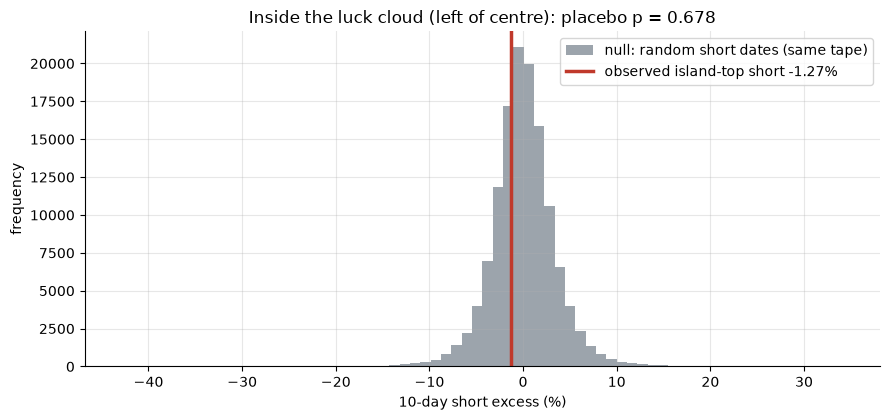

observed -1.27%  placebo p=0.678  (random shorts beat the figure ~68% of the time)


In [3]:
if HAVE_REAL:
    import numpy as np
    o,h_,lo,c = PANEL['open'],PANEL['high'],PANEL['low'],PANEL['close']
    rng = np.random.default_rng(417); H=10; dir_=-1; draws=[]
    for tk in c.columns:
        sub = pd.DataFrame({'o':o[tk],'h':h_[tk],'lo':lo[tk],'c':c[tk]}).dropna()
        oo,hh,ll,cc = [sub[k].to_numpy(float) for k in ('o','h','lo','c')]
        isl = st.detect_islands(oo,hh,ll,gap_pct=GAP,side='top')
        fr = st.forward_returns(cc,[d['signal_idx'] for d in isl],H,direction=dir_)
        if len(fr)==0: continue
        br = st.base_rate(cc,H,direction=dir_); hi=len(cc)-H-2
        for _ in range(5000):
            si=rng.integers(1,hi,size=len(fr)); e=si+1
            draws.append((dir_*(cc[e+H]/cc[e]-1.0)).mean()-br)
    draws=np.array(draws)*100
    obs = st.run_experiment(PANEL,horizon=H,side='top',gap_pct=GAP,n_draws=10)['mean']*100
    pval = float((draws>=obs).mean())
else:
    import numpy as np
    rng=np.random.default_rng(417); draws=rng.normal(0,1.2,150000); obs=R['top'][1][2]; pval=R['top'][1][7]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=70, color=GREY, alpha=.85, label='null: random short dates (same tape)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed island-top short {obs:+.2f}%')
ax.set_xlabel('10-day short excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud (left of centre): placebo p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  placebo p={pval:.3f}  (random shorts beat the figure ~{pval*100:.0f}% of the time)')

> 💡 In plain words: the red line sits to the **left** of the random cloud — random short dates beat the island top ~68% of the time (p = 0.678). Not only is there no edge, the figure is *worse* than random. This is a clean **Signal = NONE** on the headline side.

### 4c · Robustness — no gap threshold rescues it

If the figure were real, a *bigger* sealing gap (a cleaner island) should sharpen it. The 10-day short excess and its *t* across gap thresholds — it stays negative throughout.

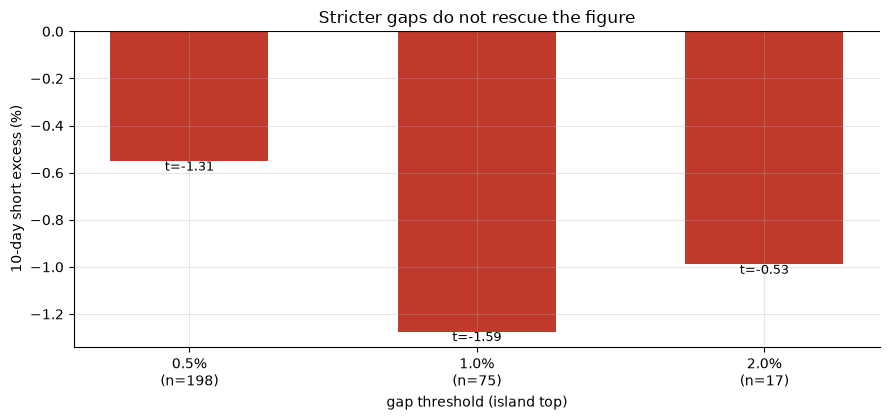

robustness (gap%, n, excess%, t, p): [(0.5, 198, -0.55, -1.31, 0.616), (1.0, 75, -1.27, -1.59, 0.673), (2.0, 17, -0.99, -0.53, 0.598)]


In [4]:
if HAVE_REAL:
    rob = []
    for gp in (0.005, 0.01, 0.02):
        r = st.run_experiment(PANEL, horizon=10, side='top', gap_pct=gp, n_draws=3000)
        rob.append((gp*100, r['n_events'], r['mean']*100, r['t'], r['p_placebo']))
else:
    rob = [(r[0], r[1], r[2], r[3], r[4]) for r in R['robust']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labs = [f'{r[0]:.1f}%\n(n={r[1]})' for r in rob]
ax.bar(labs, [r[2] for r in rob], color=RED, width=.55); ax.axhline(0, c='k', lw=.8)
for i,r in enumerate(rob): ax.annotate(f't={r[3]:+.2f}',(i,r[2]),ha='center',va='top',fontsize=9)
ax.set_xlabel('gap threshold (island top)'); ax.set_ylabel('10-day short excess (%)')
ax.set_title('Stricter gaps do not rescue the figure')
plt.tight_layout(); plt.show()
print('robustness (gap%, n, excess%, t, p):', [(r[0], r[1], round(r[2],2), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the strictest 2% gap collapses to just **17 events** (the mechanical island is genuinely rare on liquid large-caps) and the loosest (**198** events) is still negative at t = -1.31. There is no strictness at which two bracketing gaps become a tradable reversal.

### 4d · The myth check — the island bottom is just drift

A real reversal must work on **both** sides. The island-**bottom** long: its **raw** return, its **excess** over the name's drift, and its placebo *p*. The high *t* is a drift artefact.

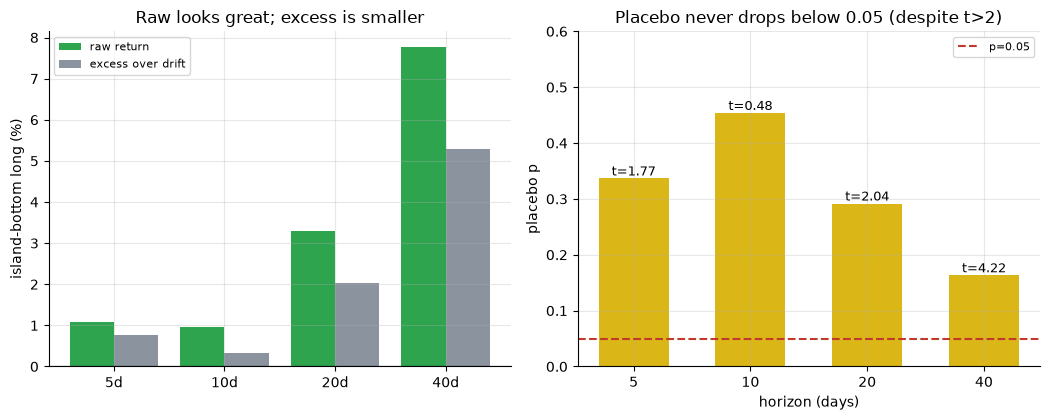

bottom excess: [0.76, 0.33, 2.02, 5.28]
bottom t: [1.77, 0.48, 2.04, 4.22]
bottom placebo p: [0.337, 0.454, 0.292, 0.163]


In [5]:
if HAVE_REAL:
    rb = [st.run_experiment(PANEL, horizon=h, side='bottom', gap_pct=GAP, n_draws=5000) for h in hs]
    raw=[r['raw_mean']*100 for r in rb]; exc=[r['mean']*100 for r in rb]; pv=[r['p_placebo'] for r in rb]; tv=[r['t'] for r in rb]
else:
    raw=[r[3] for r in R['bot']]; exc=[r[2] for r in R['bot']]; pv=[r[7] for r in R['bot']]; tv=[r[5] for r in R['bot']]
x=np.arange(len(hs))
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar(x-.2, raw, .4, color=GREEN, label='raw return'); a1.bar(x+.2, exc, .4, color=GREY, label='excess over drift')
a1.axhline(0,c='k',lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('island-bottom long (%)'); a1.set_title('Raw looks great; excess is smaller'); a1.legend(fontsize=8)
a2.bar([str(h) for h in hs], pv, color=AMBER, width=.6)
a2.axhline(0.05, ls='--', c=RED, label='p=0.05')
for i,(p,t) in enumerate(zip(pv,tv)): a2.annotate(f't={t:.2f}',(i,p),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('placebo p'); a2.set_ylim(0,.6)
a2.set_title('Placebo never drops below 0.05 (despite t>2)'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('bottom excess:', [round(v,2) for v in exc]); print('bottom t:', [round(v,2) for v in tv]); print('bottom placebo p:', [round(v,3) for v in pv])

> 💡 In plain words: this is the trap in one chart. The island bottom's 40-day *t* is **4.22** — looks bulletproof — but its placebo **p = 0.163**: random buy dates match it 16% of the time. The big *t* is the basket's multi-week up-drift compounding, not the figure. Sort the two apart and the reversal disappears.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel with **planted** island tops followed by a real **down** reversal: with zero edge the placebo must NOT light up (no false positive); with a large planted reversal it must. Both hold — so the real-tape placebo p ≈ 0.56–0.68 is a genuine nothing.

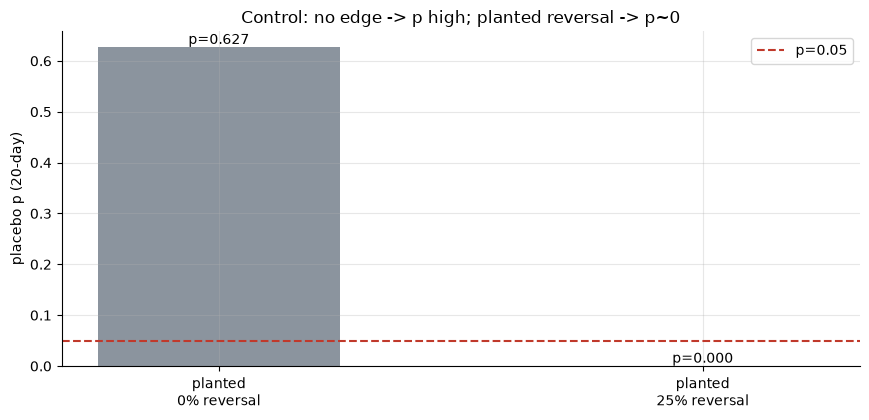

planted +0%: planted=160 n=158 excess=-0.58% t=-1.50 p=0.627 win=47%
planted +25%: planted=160 n=158 excess=+18.33% t=+59.38 p=0.000 win=100%


In [6]:
res = []
for edge in (0.0, 0.25):
    pan, truth = data.synthetic_panel(edge=edge, seed=417, n_planted=8, daily_vol=0.011, gap_pct=0.04)
    r = st.run_experiment(pan, horizon=20, side='top', gap_pct=0.02, n_draws=1500)
    res.append((edge, truth['n_planted_total'], r['n_events'], r['mean']*100, r['t'], r['p_placebo'], r['win']*100))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted\n{e*100:.0f}% reversal' for e,_,_,_,_,_,_ in res]
ps = [r[5] for r in res]
ax.bar(labels, ps, color=[GREY, GREEN], width=.5)
ax.axhline(0.05, ls='--', c=RED, label='p=0.05')
for i,p in enumerate(ps): ax.annotate(f'p={p:.3f}',(i,p),ha='center',va='bottom')
ax.set_ylabel('placebo p (20-day)'); ax.set_title('Control: no edge -> p high; planted reversal -> p~0'); ax.legend()
plt.tight_layout(); plt.show()
for e,pl,n,ls,t,p,w in res: print(f'planted {e*100:+.0f}%: planted={pl} n={n} excess={ls:+.2f}% t={t:+.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted reversal the placebo is **not beaten** (p = 0.627 — no false positive); a **+25%** planted reversal lights up at p = 0.000, t = 59, win 100%. The harness can clearly bank a real reversal — so the real tape's refusal is a true negative, not a power failure.

## 5 · The verdict

- **Signal `NONE`** — island-top short excess **negative at every horizon** (-0.70% at 5d, -1.27% at 10d), one-sample *t* peaking at **-1.59** (HAC -1.36), placebo **p = 0.678** (worse than random). Never clears |t| = 2; no gap threshold rescues it. Survivorship tilts *against* the short — so this is generous.
- **Tradability `MIRAGE`** — net of 5 bps/leg the short is **-1.38%** (10d), and the island-bottom long's t>2 (40d t = 4.22) sits **inside the placebo cloud** (p = 0.163) — pure beta. Nothing deployable, nothing to scale.
- **Reliable reversal? `BUSTED`** — the figure is asymmetric: the bearish island top **loses** (fights the up-drift), the bullish island bottom only **rides** that drift (high *t*, placebo it can't beat). A genuine reversal works on both sides on its own merits; this one works on neither.

## 6 · Could you trade it? — the SPY hook + the net picture

On the index itself the detector barely fires, and net of costs the basket short is under water. Two views of the same nothing.

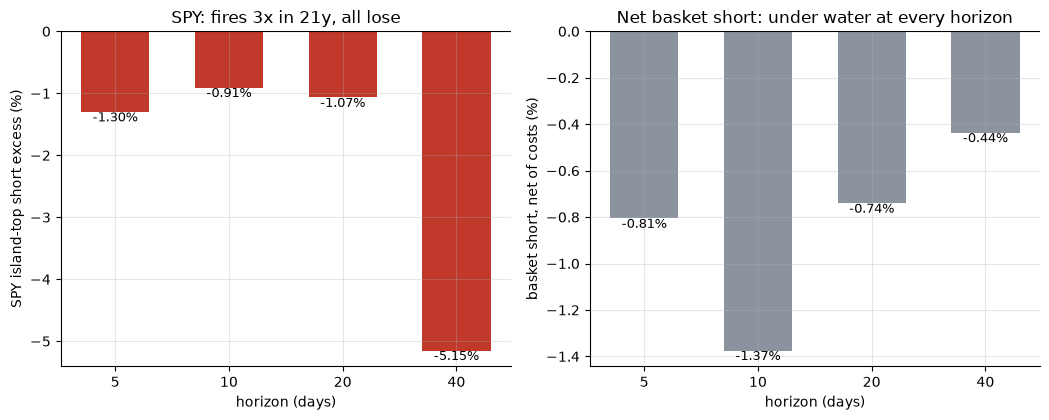

SPY island-top excess: [-1.3, -0.91, -1.07, -5.15] n: [3, 3, 3, 3]
net basket short: [-0.81, -1.37, -0.74, -0.44]


In [7]:
if HAVE_REAL:
    spy = [st.run_experiment(PANEL, horizon=h, names=['SPY'], side='top', gap_pct=GAP, n_draws=5000) for h in hs]
    spy_exc=[r['mean']*100 for r in spy]; spy_n=[r['n_events'] for r in spy]
    nv=[st.run_experiment(PANEL, horizon=h, side='top', gap_pct=GAP, n_draws=2000)['net']*100 for h in hs]
else:
    spy_exc=[r[2] for r in R['spy']]; spy_n=[r[1] for r in R['spy']]; nv=[r[8] for r in R['top']]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar([str(h) for h in hs], spy_exc, color=RED, width=.6); a1.axhline(0,c='k',lw=.8)
for i,v in enumerate(spy_exc): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top',fontsize=9)
a1.set_xlabel('horizon (days)'); a1.set_ylabel('SPY island-top short excess (%)')
a1.set_title(f'SPY: fires {spy_n[0]}x in 21y, all lose')
a2.bar([str(h) for h in hs], nv, color=GREY, width=.6); a2.axhline(0,c='k',lw=.8)
for i,v in enumerate(nv): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('basket short, net of costs (%)')
a2.set_title('Net basket short: under water at every horizon')
plt.tight_layout(); plt.show()
print('SPY island-top excess:', [round(v,2) for v in spy_exc], 'n:', spy_n)
print('net basket short:', [round(v,2) for v in nv])

> 💡 In plain words: on SPY the figure fires **3 times in 21 years** and all lose (-5.15% at 40d). On the basket, net of costs the short is **-1.38%** at 10d. There is no horizon, no universe, and no cost assumption under which the island reversal pays. **MIRAGE**, unambiguously — and here that word is earned, because the placebo and the control both confirm it.

## 7 · Going further

- **Gaps are universe-dependent.** Small-caps and single names gap far more than liquid large-caps; a wider universe gives more events but adds survivorship and cost traps. The *method* (excess + placebo) is what travels, not the basket.
- **The base-rate-and-placebo habit generalises.** Any bullish chart figure on an up-drifting asset looks like it works. The island bottom is the clean cautionary tale: a *t* of 4.2 that is **pure drift**. Always net the base rate *and* beat the random-date placebo.
- **Sibling figures.** [415-triple-top-bottom](../../415-triple-top-bottom/) (same machinery, same NONE × MIRAGE) and [363-pead-drift](../../363-pead-drift/) (the folk effect that *does* clear the bar) frame why this one doesn't.

*The reproducible core is offline and deterministic; the detector is the closest mechanical island rule, stated openly. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*